In [105]:
using HyQMOM, Plots, CSV, Tables, LaTeXStrings, DataFrames

In [114]:
# M4_file = "../out/VlasovPoisson/VlasovPoisson_moments_T25.0_M5_k0.5_ϵ0.001_p1_level8.tsv"
M_vector = [4, 5, 6, 7, 8, 20]#!, 5, 6, 7];#!, 7, 8,] # number of moments

6-element Vector{Int64}:
  4
  5
  6
  7
  8
 20

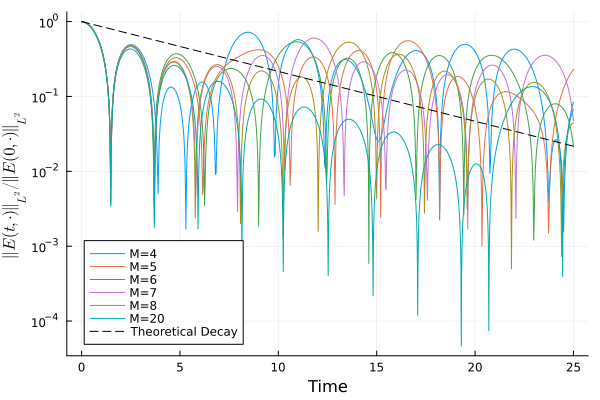

In [115]:
p = plot()
for M in M_vector
    file = "../out/VlasovPoisson/energy_moments_T25.0_M$(M)_k0.5_ϵ0.001_p1_level6.csv"
    data = CSV.read(file, DataFrame)
    plot!(
        p,
        data[!, :time], data[!, :E_L2_normalized],
        label="M=$M",
        xlabel="Time", 
        ylabel=L"∥E(t,⋅)∥_{L^2} / ∥E(0,⋅)∥_{L^2}",
        yaxis=:log
    )
    if M==M_vector[end]
        plot!(
            p,
            data[!, :time], data[!, :theoretical_decay],
            label="Theoretical Decay",
            linestyle=:dash,
            color=:black
        )
    end
end
# legend to bottom left
plot!(p, legend=:bottomleft)
display(p)
# savefig("out/VlasovPoisson/energy_all_M.pdf")